Notebook 4 - Alpha & Beta

beta = how much the portfolio moves with the market (symmetric risk)

alpha = excess return not explained by the market (skill / stock picking)

model: portfolio_return = alpha + beta * market_return

benchmark used: SPY (S&P 500 ETF, proxy for the market)

In [9]:
# Block 1 - Reload data 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'XOM']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

prices = yf.download(tickers, start='2023-01-01', end='2026-01-01', auto_adjust=True)['Close']
daily_returns = prices.pct_change().dropna()
portfolio_returns = daily_returns.dot(weights)

# download SPY as market benchmark
spy = yf.download('SPY', start = '2023-01-01', end = '2026-01-01', auto_adjust=True)['Close'].squeeze("columns")
spy_returns = spy.pct_change().dropna()

print("Portfolio data ready:", portfolio_returns.shape)
print("SPY benchmark ready:", spy_returns.shape)
print("Type check — should both say Series:")
print(type(portfolio_returns), type(spy_returns))

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Portfolio data ready: (751,)
SPY benchmark ready: (751,)
Type check — should both say Series:
<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


In [11]:
# Block 2 - Align dates
# portfolio and SPY might have slightly different trading calendars (holidays, etc.)
# so we align both series on their common dates before regressing
# without this, mismatched dates would silently corrupt the regression

aligned = pd.DataFrame({
    'portfolio': portfolio_returns,
    'spy': spy_returns
}).dropna()

print("Aligned data shape:", aligned.shape)
print(aligned.head())

Aligned data shape: (751, 2)
            portfolio       spy
Date                           
2023-01-04  -0.005823  0.007720
2023-01-05  -0.008363 -0.011413
2023-01-06   0.023083  0.022932
2023-01-09   0.001185 -0.000567
2023-01-10   0.012939  0.007013


In [ ]:
# Block 3 - Calculate alpha and beta

# line regression gives us slope (beta) and intercept (daily alpha) directly 

slope, intercept, r_value, p_value, std_err = stats.linregress(
    aligned['spy'], aligned['portfolio']
)

beta = slope
daily_alpha = intercept

annual_alpha = daily_alpha * 252

# r-squared tells us how much of the portfolio's movement is explained by the market
r_squared = r_value ** 2

print(f"Beta: {beta:.3f}")
print(f"Daily Alpha: {daily_alpha:.5f}")
print(f"Annualized Alpha: {annual_alpha:.2%}")
print(f"R-squared: {r_squared:.3f}")
print(f"P-value (statistical significance of beta): {p_value:.5f}")

Beta: 0.990
Daily Alpha: 0.00024
Annualized Alpha: 6.09%
R-squared: 0.795
P-value (statistical significance of beta): 0.00000


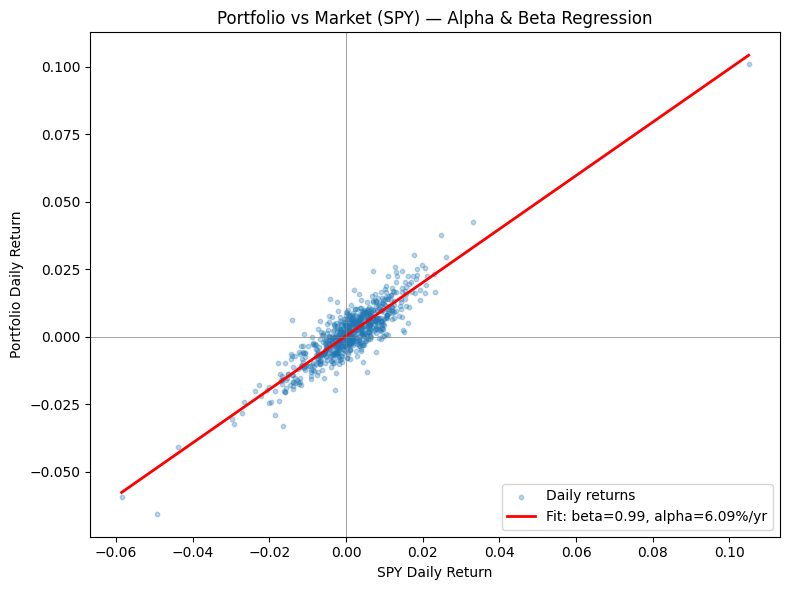

In [ ]:
# BLOCK 4 - Visualize the Regression
# scatter of daily returns + the fitted regression line
# the slope of this line IS the beta

plt.figure(figsize=(8, 6))
plt.scatter(aligned['spy'], aligned['portfolio'], alpha=0.3, s=10, label='Daily returns')

# regression line across the range of SPY returns observed
x_line = np.linspace(aligned['spy'].min(), aligned['spy'].max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='red', linewidth=2,
          label=f'Fit: beta={beta:.2f}, alpha={annual_alpha:.2%}/yr')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('SPY Daily Return')
plt.ylabel('Portfolio Daily Return')
plt.title('Portfolio vs Market (SPY) — Alpha & Beta Regression')
plt.legend()
plt.tight_layout()
plt.savefig('../data/alpha_beta.png', dpi=150)
plt.show()

Beta: 0.990 — portfolio moves almost exactly 1-for-1 with the market

Annualized Alpha: 6.09% — portfolio generated ~6.09% of return per year beyond what its market exposure alone would predict. That's a genuinely good result to highlight.

R-squared: 0.795 — about 79.5% of your portfolio's daily movement is explained by SPY alone. The remaining ~20% is stock-specific movement (some of which is what's producing that alpha).

P-value: 0.00000 — the beta estimate is highly statistically significant, not noise.